# Discrete Probability and Energy-Based Models

This notebook introduces the core ideas behind **energy-based models (EBMs)** for discrete random variables and shows how to sample from them using **hamon**.

By the end you will:
- Understand what an energy function is and how the **Boltzmann distribution** assigns probabilities to discrete states
- Develop intuition for the role of inverse temperature $\beta$
- Know what **factor graphs** are and why they matter for efficient sampling
- Run your first hamon sampling code

## Why discrete models?

Many scientific and engineering problems are fundamentally about discrete choices:

- **Protein folding** — each residue adopts one of a finite set of amino acid identities or rotamer states
- **Alloy design** — each lattice site is occupied by one of several element types
- **Neural coding** — neurons spike or stay silent in each time bin
- **Combinatorial optimization** — binary decisions (include/exclude, on/off) define a solution

In all of these cases we want to reason about a **probability distribution over discrete configurations**. Energy-based models give us a principled, flexible way to do exactly that.

## Energy functions and the Boltzmann distribution

An **energy-based model** assigns a scalar energy $E(x)$ to every possible configuration $x$. Lower energy means higher probability, via the **Boltzmann distribution**:

$$P(x) = \frac{1}{Z} \exp\bigl(-E(x)\bigr), \qquad Z = \sum_{x'} \exp\bigl(-E(x')\bigr)$$

The normalization constant $Z$ (the **partition function**) sums over every possible state. For small systems we can compute it exactly; for large systems we resort to sampling.

Let's start with a toy system: three binary variables $s_1, s_2, s_3 \in \{-1, +1\}$, with energy

$$E(s) = -(J_{12}\, s_1 s_2 + J_{23}\, s_2 s_3 + J_{13}\, s_1 s_3)$$

where $J_{ij}$ are coupling constants. When $J > 0$, aligned spins ($s_i = s_j$) lower the energy.

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np

# Coupling constants
J12, J23, J13 = 1.0, 0.8, 0.5


def energy(s1, s2, s3):
    return -(J12 * s1 * s2 + J23 * s2 * s3 + J13 * s1 * s3)


# Enumerate all 2^3 = 8 configurations
spins = [-1, +1]
configs = list(itertools.product(spins, spins, spins))
energies = np.array([energy(*c) for c in configs])
labels = ["".join("+" if s == 1 else "-" for s in c) for c in configs]

print("Config  Energy")
for lbl, e in zip(labels, energies):
    print(f"  {lbl}   {e:+.1f}")

Config  Energy
  ---   -2.3
  --+   +0.3
  -+-   +1.3
  -++   +0.7
  +--   +0.7
  +-+   +1.3
  ++-   +0.3
  +++   -2.3


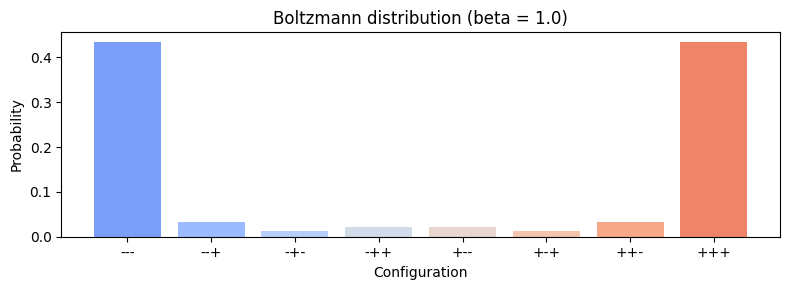

In [2]:
# Compute exact Boltzmann probabilities
beta = 1.0
log_probs = -beta * energies
log_probs -= log_probs.max()  # for numerical stability
probs = np.exp(log_probs)
probs /= probs.sum()

fig, ax = plt.subplots(figsize=(8, 3))
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(configs)))
ax.bar(labels, probs, color=colors)
ax.set_xlabel("Configuration")
ax.set_ylabel("Probability")
ax.set_title(f"Boltzmann distribution (beta = {beta})")
plt.tight_layout()
plt.show()

### The role of inverse temperature $\beta$

The parameter $\beta$ controls how sharply the distribution concentrates on low-energy states:

- $\beta \to 0$ (high temperature): all states are equally likely — maximum entropy
- $\beta \to \infty$ (low temperature): probability concentrates on the ground state(s)

Let's visualize this.

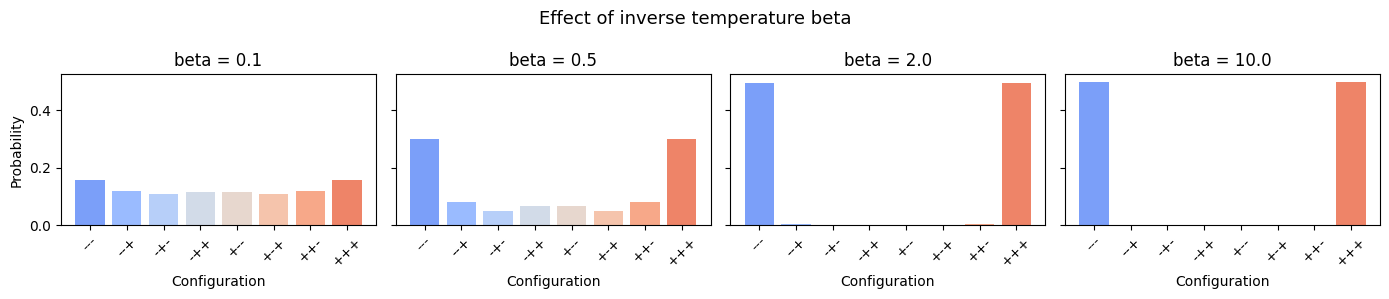

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, beta in zip(axes, [0.1, 0.5, 2.0, 10.0]):
    log_p = -beta * energies
    log_p -= log_p.max()
    p = np.exp(log_p)
    p /= p.sum()
    ax.bar(labels, p, color=colors)
    ax.set_title(f"beta = {beta}")
    ax.set_xlabel("Configuration")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Probability")
fig.suptitle("Effect of inverse temperature beta", fontsize=13)
plt.tight_layout()
plt.show()

## From energy functions to factor graphs

The energy function above decomposes naturally as a sum of **local terms** (factors), each involving only a small subset of variables:

$$E(s) = \underbrace{-J_{12}\, s_1 s_2}_{\text{factor 1}} + \underbrace{-J_{23}\, s_2 s_3}_{\text{factor 2}} + \underbrace{-J_{13}\, s_1 s_3}_{\text{factor 3}}$$

This decomposition defines a **factor graph**: variables are nodes, and each factor connects the variables it depends on. This structure is the key to efficient sampling — we can update groups of variables in parallel, as long as they don't share any factors.

### The Potts model

Let's move to a richer example: the **Potts model**, where each variable $x_i$ takes one of $K$ categorical values (colors). The energy favors neighboring sites having the same color:

$$E(x) = -\sum_{(i,j) \in \text{edges}} J \cdot \delta(x_i, x_j)$$

where $\delta(a,b) = 1$ if $a=b$ and $0$ otherwise. We'll build a 4×4 Potts grid with $K=4$ colors using hamon.

In [4]:
import jax
import jax.numpy as jnp
import networkx as nx

from hamon import CategoricalNode, Block
from hamon.models.discrete_ebm import CategoricalEBMFactor

# Grid parameters
ROWS, COLS = 4, 4
N_COLORS = 4
J = 1.0  # coupling strength

# Create one CategoricalNode per grid site
nodes = [[CategoricalNode() for _ in range(COLS)] for _ in range(ROWS)]
flat_nodes = [nodes[r][c] for r in range(ROWS) for c in range(COLS)]

# Build the interaction graph (nearest-neighbor edges)
G = nx.grid_2d_graph(ROWS, COLS)
edges = list(G.edges())

# For each edge, create a factor with a weight tensor W[x_i, x_j] = J * delta(x_i, x_j)
head_nodes = [nodes[r1][c1] for (r1, c1), (r2, c2) in edges]
tail_nodes = [nodes[r2][c2] for (r1, c1), (r2, c2) in edges]

# Weight tensor: J * identity matrix, batched over all edges
W = J * jnp.tile(jnp.eye(N_COLORS, dtype=jnp.float32), (len(edges), 1, 1))

factor = CategoricalEBMFactor(
    node_groups=[Block(head_nodes), Block(tail_nodes)],
    weights=W,
)

print(f"Grid: {ROWS}x{COLS} = {ROWS * COLS} sites")
print(f"Edges: {len(edges)}")
print(f"Weight tensor shape: {W.shape}  (edges x colors x colors)")

Grid: 4x4 = 16 sites
Edges: 24
Weight tensor shape: (24, 4, 4)  (edges x colors x colors)


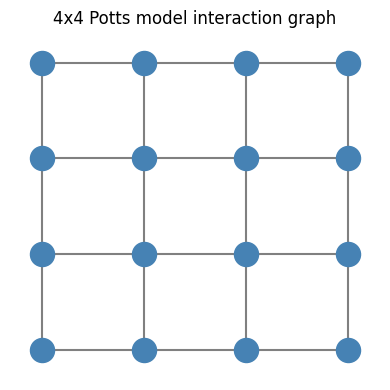

In [5]:
# Visualize the factor graph
fig, ax = plt.subplots(figsize=(4, 4))
pos = {(r, c): (c, -r) for r in range(ROWS) for c in range(COLS)}
nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=False,
    node_color="steelblue",
    node_size=300,
    edge_color="gray",
    width=1.5,
)
ax.set_title("4x4 Potts model interaction graph")
plt.tight_layout()
plt.show()

## Your first hamon sample

To sample from this Potts model we need to:

1. **Partition the variables into blocks** that can be updated simultaneously. On a grid, a 2-coloring (checkerboard pattern) works: all "black" squares are conditionally independent given the "white" squares, and vice versa.

2. **Build a sampling program** that tells hamon which blocks to update, in what order, and using which conditional sampler.

3. **Run the sampler** to collect samples from the Boltzmann distribution.

In [6]:
from hamon import BlockGibbsSpec, SamplingSchedule, sample_states
from hamon.factor import FactorSamplingProgram
from hamon.models.discrete_ebm import CategoricalGibbsConditional

# Graph-color the grid to find independent sets
coloring = nx.coloring.greedy_color(G, strategy="DSATUR")
n_colors_graph = max(coloring.values()) + 1
print(f"Graph coloring uses {n_colors_graph} colors (checkerboard = 2)")

# Build blocks from the graph coloring
color_groups = [[] for _ in range(n_colors_graph)]
for (r, c), color in coloring.items():
    color_groups[color].append(nodes[r][c])

free_blocks = [Block(group) for group in color_groups]

# Build the Gibbs specification and sampling program
node_sd = {CategoricalNode: jax.ShapeDtypeStruct((), jnp.uint8)}
spec = BlockGibbsSpec(free_blocks, clamped_blocks=[], node_shape_dtypes=node_sd)

# One conditional sampler per block
samplers = [CategoricalGibbsConditional(n_categories=N_COLORS) for _ in free_blocks]

# Combine factor interaction groups with the Gibbs spec
interaction_groups = factor.to_interaction_groups()
program = FactorSamplingProgram(spec, samplers, [factor], [])

print(f"Free blocks: {len(free_blocks)} (sizes: {[len(b) for b in free_blocks]})")

Graph coloring uses 2 colors (checkerboard = 2)
Free blocks: 2 (sizes: [8, 8])


In [7]:
# Initialize all sites to random colors
key = jax.random.key(42)
init_state = [
    jax.random.randint(
        jax.random.fold_in(key, i), shape=(len(b),), minval=0, maxval=N_COLORS
    ).astype(jnp.uint8)
    for i, b in enumerate(free_blocks)
]

# Define sampling schedule
schedule = SamplingSchedule(n_warmup=200, n_samples=500, steps_per_sample=2)

# Run!
obs_block = Block(flat_nodes)
key, subkey = jax.random.split(key)
samples = sample_states(subkey, program, schedule, init_state, [], [obs_block])
samples = samples[0]  # shape: (n_samples, n_sites)

print(f"Collected {samples.shape[0]} samples of {samples.shape[1]} variables")

Collected 500 samples of 16 variables


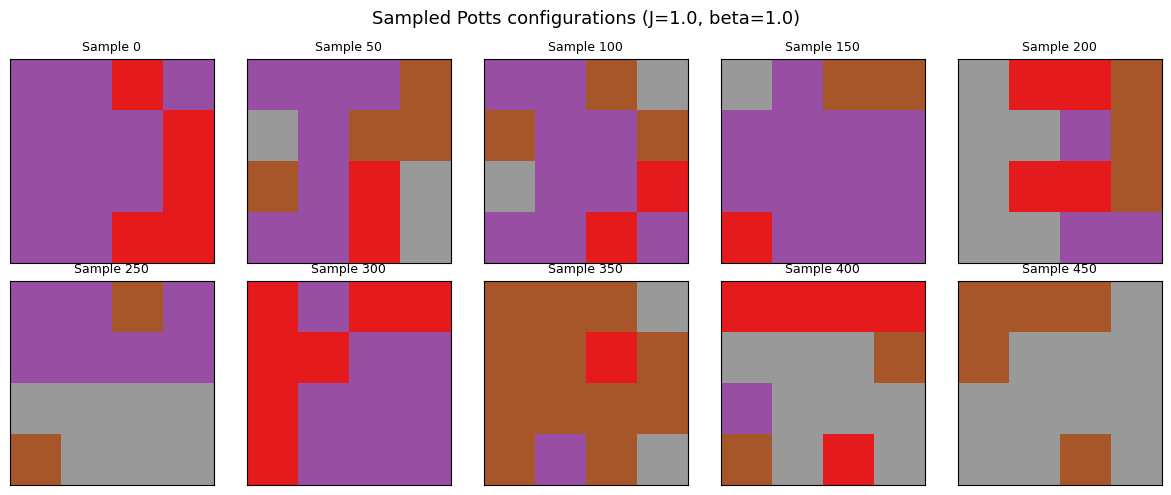

In [8]:
# Visualize some sampled configurations
cmap = plt.cm.Set1

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    sample_idx = idx * (len(samples) // 10)
    grid = np.array(samples[sample_idx]).reshape(ROWS, COLS)
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=N_COLORS - 1, interpolation="nearest")
    ax.set_title(f"Sample {sample_idx}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"Sampled Potts configurations (J={J}, beta=1.0)", fontsize=13)
plt.tight_layout()
plt.show()

Notice the **domain formation**: neighboring sites tend to share the same color, because aligned colors lower the energy. This is a hallmark of the Potts model and demonstrates that hamon is correctly sampling from the Boltzmann distribution.

## Key takeaways

- An **energy function** $E(x)$ defines a probability distribution over discrete configurations via the Boltzmann distribution
- **Inverse temperature** $\beta$ controls the sharpness: high $\beta$ concentrates on low-energy states
- Most useful energy functions decompose into **local factors**, forming a **factor graph**
- **Graph coloring** identifies groups of variables that can be updated simultaneously (blocks)
- **hamon** handles the JAX compilation and vectorization so you can focus on the model

In the next notebook, we'll dive deeper into how **block Gibbs sampling** works and build a complete sampling pipeline for Ising (binary spin) models.